In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import warnings 
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("data/titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [4]:
df.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)

In [5]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S


# EDA

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Cabin     204 non-null    object 
 8   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 62.8+ KB


In [7]:
# categorical --> encoding --> numerical

In [8]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
# outliers --> Fare, Age --> we need to handle them

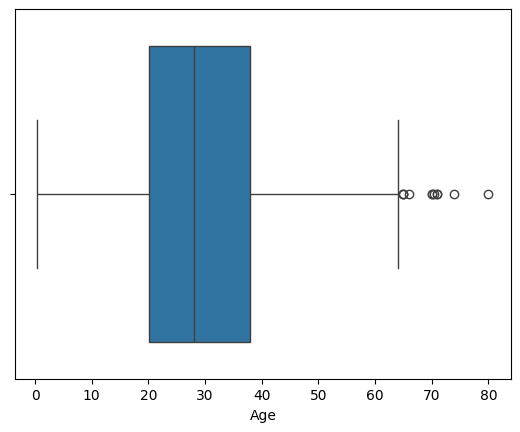

In [10]:
sns.boxplot(x="Age", data=df)
plt.show()

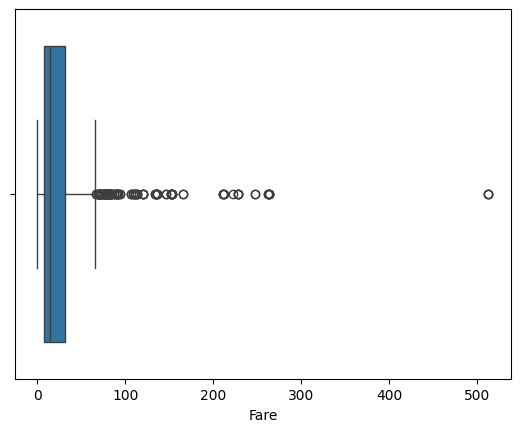

In [11]:
sns.boxplot(x="Fare", data=df)
plt.show()

In [12]:
len(df)

891

In [13]:
df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [14]:
# drop cabin feature, impute for nulls in Age feature

In [15]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S


In [16]:
# scaling for features Age, Fare

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Cabin     204 non-null    object 
 8   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 62.8+ KB


In [18]:
df.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Cabin',
       'Embarked'],
      dtype='object')

In [19]:
df.Sex.value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [20]:
df.Embarked.value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [21]:
df.Pclass.value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [22]:
df.SibSp.value_counts()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

<Axes: xlabel='Embarked', ylabel='count'>

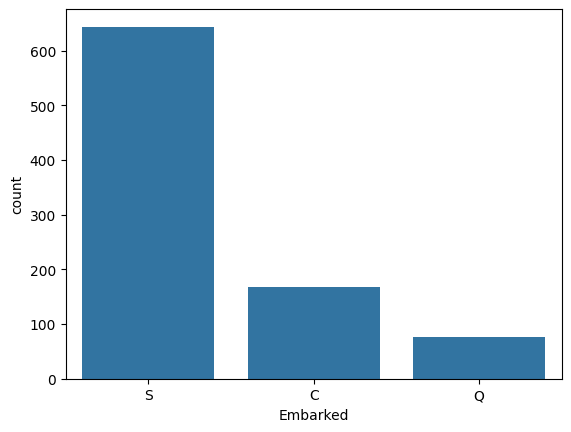

In [23]:
sns.countplot(x="Embarked", data=df)

<Axes: >

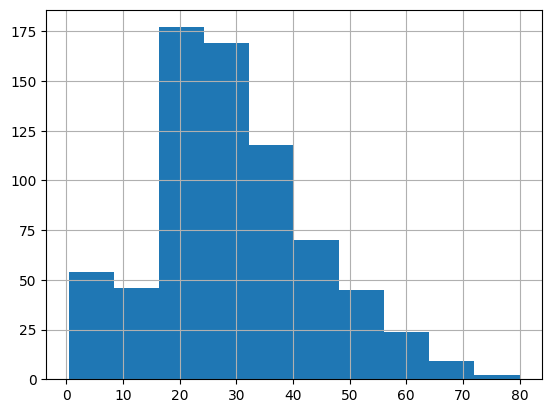

In [24]:
df.Age.hist()

In [25]:
df.Survived.value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

<Axes: xlabel='Survived', ylabel='count'>

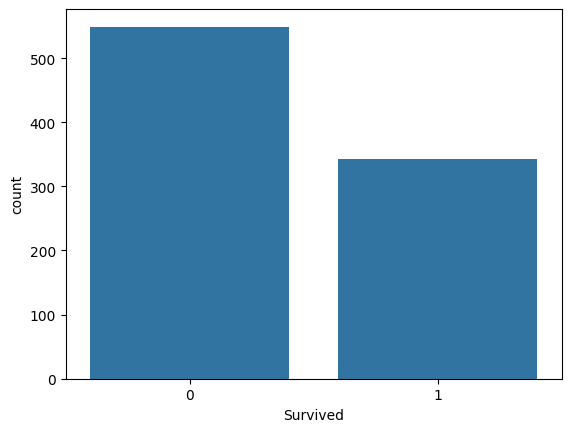

In [26]:
sns.countplot(x="Survived", data=df)

# Preprocessing

In [27]:
# 1. handle nulls
# 2. Handle outliers
# 3. encoding
# 4. Scaling
# 5. feature selection

## handling nulls

In [28]:
df.drop(columns="Cabin", axis=1, inplace=True)

In [29]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [30]:
df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

In [31]:
# df['Embarked'].mode()

In [32]:
df.Embarked.fillna(df['Embarked'].mode()[0], inplace=True)

In [33]:
df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      0
dtype: int64

<Axes: xlabel='Pclass', ylabel='Age'>

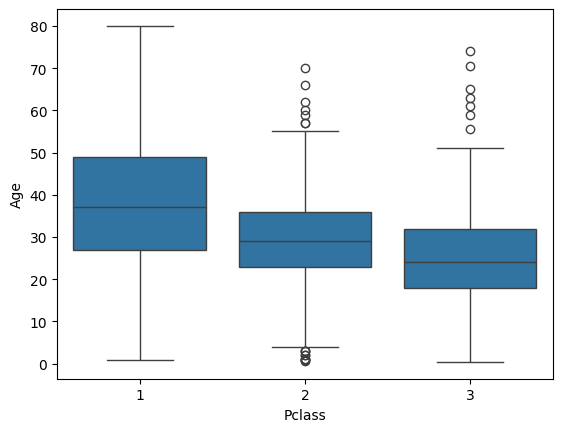

In [34]:
sns.boxplot(data=df, x='Pclass', y="Age")

In [35]:
pclass1_age_mean = df[df['Pclass'] == 1]['Age'].mean()
pclass2_age_mean = df[df['Pclass'] == 2]['Age'].mean()
pclass3_age_mean = df[df['Pclass'] == 3]['Age'].mean()

In [36]:
def impute_age(cols):
    Age = cols['Age']
    Pclass = cols['Pclass']
    if pd.isnull(Age):
        if Pclass == 1:
            return int(df[df['Pclass'] == 1]['Age'].mean())
        elif Pclass == 2:
            return int(df[df['Pclass'] == 2]['Age'].mean())
        else:
            return int(df[df['Pclass'] == 3]['Age'].mean())
    else:
        return Age

In [37]:
df['Age'] = df[['Age', 'Pclass']].apply(impute_age, axis=1)

In [38]:
df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [39]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


## Outliers

In [40]:
# age
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['Age'] >= lower_bound) & (df['Age'] <= upper_bound)]

In [41]:
# fare
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['Fare'] >= lower_bound) & (df['Fare'] <= upper_bound)]

## Splitting

In [42]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
5,0,3,male,25.0,0,0,8.4583,Q


In [43]:
x = df.drop(columns="Survived", axis=1)
y = df["Survived"]

In [44]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

# Encoding

In [45]:
from sklearn.preprocessing import OrdinalEncoder

In [46]:
ore = OrdinalEncoder()

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 753 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  753 non-null    int64  
 1   Pclass    753 non-null    int64  
 2   Sex       753 non-null    object 
 3   Age       753 non-null    float64
 4   SibSp     753 non-null    int64  
 5   Parch     753 non-null    int64  
 6   Fare      753 non-null    float64
 7   Embarked  753 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 52.9+ KB


In [48]:
x_train[['Sex', 'Embarked']] = ore.fit_transform(x_train[['Sex', 'Embarked']])
x_test[['Sex', 'Embarked']] = ore.transform(x_test[['Sex', 'Embarked']])

## Scaling

In [51]:
from sklearn.preprocessing import MinMaxScaler

In [53]:
mns = MinMaxScaler()
x_train[['Age', 'Fare']] = mns.fit_transform(x_train[['Age', 'Fare']])
x_test[['Age', 'Fare']] = mns.transform(x_test[['Age', 'Fare']])

In [55]:
x_train.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
282,3,1.0,0.246377,0,0,0.300578,2.0
5,3,1.0,0.405797,0,0,0.242775,1.0
472,2,0.0,0.565217,1,2,0.722543,2.0
44,3,0.0,0.289855,0,0,0.173410,1.0
198,3,0.0,0.405797,0,0,0.127168,1.0


In [56]:
x_test.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
95,3,1.0,0.362319,0,0,0.046532,2.0
421,3,1.0,0.304348,0,0,0.044701,1.0
677,3,0.0,0.260870,0,0,0.056888,2.0
143,3,1.0,0.275362,0,0,0.039017,1.0
25,3,0.0,0.550725,1,5,0.181431,2.0


# Classification Using Logistic Regression

In [57]:
from sklearn.linear_model import LogisticRegression

In [58]:
lr = LogisticRegression()

In [59]:
lr.fit(x_train, y_train)

LogisticRegression()

In [60]:
y_hat = lr.predict(x_test)
y_hat

array([0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1])

In [61]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_hat)

0.8145695364238411